In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis)
from sklearn import datasets

from scipy import linalg

import statsmodels.api as sm

Quadratic discriminant analysis

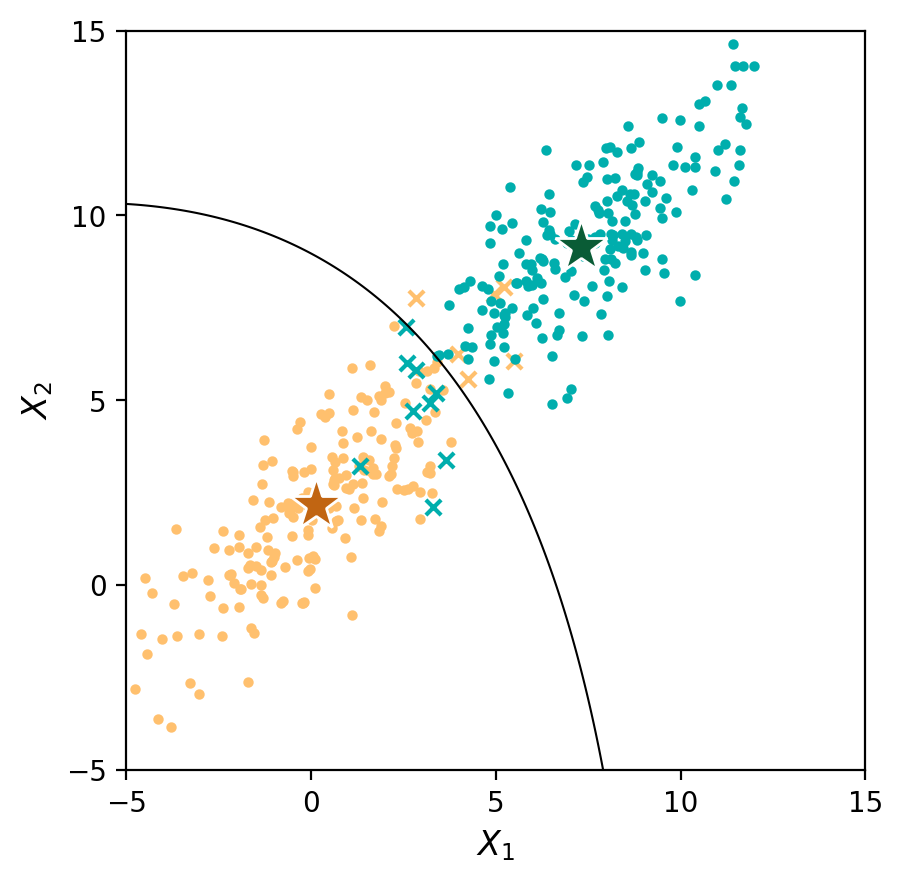

In [2]:
# def dataset_fixed_cov():
#   n, dim = 3, 2
#   np.random.seed(0)
#   C = np.array([[0.0, -0.23], [0.83, 0.23]])
#   X = np.r_[np.dot(np.random.randn(n, dim), C),
#           np.dot(np.random.randn(n, dim), C)+np.array([1,1])]
#   y = np.hstack((np.zeros(n), np.ones(n)))
#   return X, y


# dataset_fixed_cov()

perform_LDA = 0 # set to 1 to perform LDA, otherwise perform QDA

# Generate two Gaussian samples by specifying the mean and covariance matrix of each
mean_1, mean_2 = [0,2], [7,9]
cov_1, cov_2 = [[5, 4],[4,5]], [[5,4],[4,5]]
n = 200 # number of data points per class

np.random.seed(0)
X_1 = np.random.multivariate_normal(mean_1, cov_1, size=n)
Y_1 = np.zeros(n)
X_2 = np.random.multivariate_normal(mean_2, cov_2, size=n)
Y_2 = np.ones(n)

X = np.r_[X_1, X_2]
y = np.r_[Y_1, Y_2]

da = LinearDiscriminantAnalysis(solver="svd", store_covariance=True) if perform_LDA == 1 else QuadraticDiscriminantAnalysis(priors=None, store_covariance=True)
y_pred = da.fit(X, y).predict(X)

### Plot QDA Results ###

# plot data
tp = y == y_pred # true positive
tp0, tp1 = tp[y == 0], tp[y == 1]
X0, X1 = X[y == 0], X[y == 1]
X0_tp, X0_fp = X0[tp0], X0[~tp0]
X1_tp, X1_fp = X1[tp1], X1[~tp1]

# plot colors, axis limits etc.
c2 = "#00AEAD"
c1 = "#FFC06E"
axis_lim = [-5, 15]

# plot true positives for class 0 as dots and false positives for class 0 as crosses
plt.figure(dpi=200)
plt.scatter(X0_tp[:,0], X0_tp[:,1], marker=".", color=c1, s=30)
plt.scatter(X0_fp[:,0], X0_fp[:,1], marker="x", color=c1, s=30)

# plot true positives for class 1 as dots and false positives for class 1 as crosses
plt.scatter(X1_tp[:,0], X1_tp[:,1], marker=".", color=c2, s=30)
plt.scatter(X1_fp[:,0], X1_fp[:,1], marker="x", color=c2, s=30)


# generate the mesh grid coordinates and plot the decision boundary
nx, ny = 200, 200
x_min, x_max = axis_lim[0], axis_lim[1]
y_min, y_max = axis_lim[0], axis_lim[1]
xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx), np.linspace(y_min, y_max, ny))
Z = da.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z[:,1].reshape(xx.shape)
# plt.pcolormesh(xx, yy, Z, cmap="BrBG", norm=matplotlib.colors.Normalize(0.0, 1.0), zorder=0)
plt.contour(xx, yy, Z, [0.5], linewidths=0.75, colors="k")

# plot the fitted class means as stars
plt.plot(da.means_[0][0], da.means_[0][1], "*", color="#C16512", markersize=20, markeredgecolor="w")
plt.plot(da.means_[1][0], da.means_[1][1], "*", color="#0A5C36", markersize=20, markeredgecolor="w")

ax = plt.gca()
ax.set_xlabel("$X_1$", fontsize=12)
ax.set_ylabel("$X_2$", fontsize=12)
ax.set_xlim(axis_lim)
ax.set_ylim(axis_lim)
ax.set_xticks(np.arange(axis_lim[0], axis_lim[1]+0.1, 5))
ax.set_yticks(np.arange(axis_lim[0], axis_lim[1]+0.1, 5))
ax.set_aspect('equal', adjustable='box')
plt.show()

Linear Discriminant Analysis for the Iris dataset

,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


Cross validation accuracy: 0.9800000000000001.

The probability that unknown sample 0 belongs to each of the 3 classes (setosa, versicolor, virginica) is [1. 0. 0.], and is classified as setosa.
The probability that unknown sample 1 belongs to each of the 3 classes (setosa, versicolor, virginica) is [0.     0.9705 0.0295], and is classified as versicolor.
The probability that unknown sample 2 belongs to each of the 3 classes (setosa, versicolor, virginica) is [0.     0.3024 0.6976], and is classified as virginica.
The probability that unknown sample 3 belongs to each of the 3 classes (setosa, versicolor, virginica) is [0.     0.6629 0.3371], and is classified as versicolor.


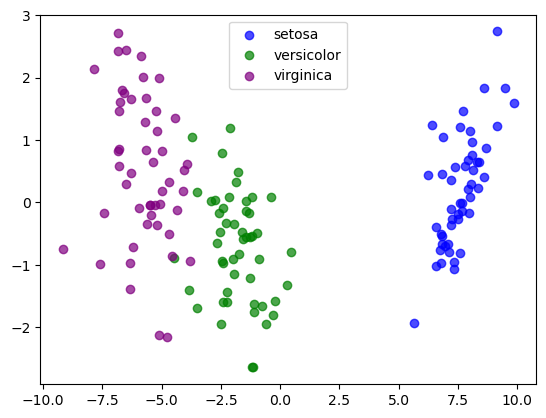

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn import datasets
import matplotlib.pyplot as plt

# load the iris dataset
df = pd.read_csv('iris_dataset.csv')
display(df)

# fit the model
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

model = LinearDiscriminantAnalysis()
model.fit(X, y)

# evaluate the model by k-fold cross-validation
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=1)

print(f"Cross validation accuracy: {np.mean(scores)}.\n")

# predict the class of 4 unknown sample with the following feature values:
# sample 1: sepal_length = 5 cm, sepal_width = 2 cm, petal_length = 1 cm, petal_width = 0.4 cm
# sample 2: sepal_length = 2 cm, sepal_width = 3 cm, petal_length = 0.1 cm, petal_width = 3 cm
# sample 3: sepal_length = 3 cm, sepal_width = 5 cm, petal_length = 2 cm, petal_width = 3 cm
# sample 4: sepal_length = 4 cm, sepal_width = 0.3 cm, petal_length = 4 cm, petal_width = 1 cm

X_unknown = pd.DataFrame(data=[[5, 2, 1, 0.4], [2, 3, 0.1, 3], [3, 5, 2, 3], [4, 0.3, 4, 1]],
                         columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

# predict the probability that each unknown sample belongs to each of the 3 classes
X_unknown_class_prob_pred = model.predict_proba(X_unknown).round(4) # round to 4 decimal places

# predict the class for each unknown sample
X_unknown_class_pred = model.predict(X_unknown)

_ = [print(f"The probability that unknown sample {i} belongs to each of the 3 classes (setosa, versicolor, virginica) is {class_prob}, and is classified as {class_name}.")
for i, (class_prob, class_name) in enumerate(zip(X_unknown_class_prob_pred, X_unknown_class_pred))]

# Visualize the results (optional)
model = LinearDiscriminantAnalysis()
y = df["target"]
data_plot = model.fit(X, y).transform(X) # the .transform() method projects data to maximize class separation
target_names = ['setosa', 'versicolor', 'virginica']
colors = ['blue', 'green', 'purple']
lw = 2 # line width for plotting
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
  plt.scatter(data_plot[y == i, 0], data_plot[y == i, 1], alpha = 0.7, color=color, label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.show()